Гипотеза 6. Балансировка классов

Гипотеза: Дополнительная ручная балансировка классов улучшит качество модели по сравнению со встроенной автоматической балансировкой CatBoost.

In [1]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder

In [2]:
df_train = pd.read_csv('train_final_processed.csv')
df_test = pd.read_csv('test_final_processed.csv')

In [3]:
X_train_full = df_train.drop(['sk_id_curr', 'target'], axis=1)
y_train_full = df_train['target']

if y_train_full.dtype == 'object' or len(y_train_full.unique()) > 2:
    y_train_full = y_train_full.map({'0': 0, '1': 1}).fillna(0).astype(int)

common_cols = X_train_full.columns.intersection(df_test.drop(['sk_id_curr'], axis=1).columns)
if len(common_cols) < 10:
    print("Предупреждение")
X_train_full = X_train_full[common_cols]
df_test_processed = df_test[common_cols]

In [4]:
cat_cols = [col for col in common_cols if X_train_full[col].dtype == 'object']
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X_train_full[col] = X_train_full[col].astype(str).fillna('missing')
    df_test_processed[col] = df_test_processed[col].astype(str).fillna('missing')
    
    all_values = pd.concat([X_train_full[col], df_test_processed[col]], axis=0).unique()
    le.fit(all_values) 
    
    X_train_full[col] = le.transform(X_train_full[col])
    df_test_processed[col] = le.transform(df_test_processed[col])

C:\Users\klmv0\AppData\Local\Temp\ipykernel_19168\1254183696.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_processed[col] = df_test_processed[col].astype(str).fillna('missing')
C:\Users\klmv0\AppData\Local\Temp\ipykernel_19168\1254183696.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_processed[col] = le.transform(df_test_processed[col])
C:\Users\klmv0\AppData\Local\Temp\ipykernel_19168\1254183696.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from

In [5]:
for col in X_train_full.select_dtypes(include=['float64', 'int64']).columns:
    percentile_99 = X_train_full[col].quantile(0.99)
    median_value = X_train_full[col].median()
    X_train_full[col] = X_train_full[col].apply(lambda x: median_value if x > percentile_99 else x)
    df_test_processed[col] = df_test_processed[col].apply(lambda x: median_value if x > percentile_99 else x)

C:\Users\klmv0\AppData\Local\Temp\ipykernel_19168\4081750730.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_processed[col] = df_test_processed[col].apply(lambda x: median_value if x > percentile_99 else x)
C:\Users\klmv0\AppData\Local\Temp\ipykernel_19168\4081750730.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_processed[col] = df_test_processed[col].apply(lambda x: median_value if x > percentile_99 else x)
C:\Users\klmv0\AppData\Local\Temp\ipykernel_19168\4081750730.py:5: Setting

In [7]:
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full)

In [13]:
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights_dict = dict(zip(classes, weights))


In [14]:
cat_model_optimal = CatBoostClassifier(
    class_weights=class_weights_dict,
    iterations=1000,     
    learning_rate=0.03,       
    depth=7,          
    random_state=42,
    l2_leaf_reg=2,  
    eval_metric='AUC',
    loss_function='Logloss',
    verbose=100)

cat_model_optimal.fit(X_train, y_train, eval_set=(X_val, y_val), cat_features=cat_cols)

0:	test: 0.7019905	best: 0.7019905 (0)	total: 1.54s	remaining: 25m 40s
100:	test: 0.7599378	best: 0.7599378 (100)	total: 1m 42s	remaining: 15m 9s
200:	test: 0.7700095	best: 0.7700095 (200)	total: 3m 22s	remaining: 13m 23s
300:	test: 0.7742502	best: 0.7742502 (300)	total: 5m 2s	remaining: 11m 41s
400:	test: 0.7769670	best: 0.7769670 (400)	total: 6m 47s	remaining: 10m 8s
500:	test: 0.7795605	best: 0.7795605 (500)	total: 8m 29s	remaining: 8m 27s
600:	test: 0.7807897	best: 0.7808198 (592)	total: 10m 16s	remaining: 6m 49s
700:	test: 0.7816957	best: 0.7817058 (697)	total: 12m 19s	remaining: 5m 15s
800:	test: 0.7819124	best: 0.7819460 (765)	total: 14m 1s	remaining: 3m 29s
900:	test: 0.7823505	best: 0.7823505 (900)	total: 15m 38s	remaining: 1m 43s
999:	test: 0.7825303	best: 0.7825329 (951)	total: 17m 16s	remaining: 0us

bestTest = 0.7825328575
bestIteration = 951

Shrink model to first 952 iterations.


In [15]:
y_val_pred_proba = cat_model_optimal.predict_proba(X_val)[:, 1]
val_metrics = {
    'ROC-AUC': roc_auc_score(y_val, y_val_pred_proba),
    'Accuracy': accuracy_score(y_val, y_val_pred_proba > 0.5),
    'Precision': precision_score(y_val, y_val_pred_proba > 0.5),
    'Recall': recall_score(y_val, y_val_pred_proba > 0.5),
    'F1-Score': f1_score(y_val, y_val_pred_proba > 0.5)
}
for metric, value in val_metrics.items():
    print(f'Validation {metric}: {value:.4f}')

Validation ROC-AUC: 0.7825
Validation Accuracy: 0.7491
Validation Precision: 0.1938
Validation Recall: 0.6675
Validation F1-Score: 0.3004


In [16]:
test_pred_proba = cat_model_optimal.predict_proba(df_test_processed)[:, 1]
submission = pd.DataFrame({
    'sk_id_curr': df_test['sk_id_curr'],
    'target': test_pred_proba
})
submission.to_csv('submission_hypothesis_6.csv', index=False)

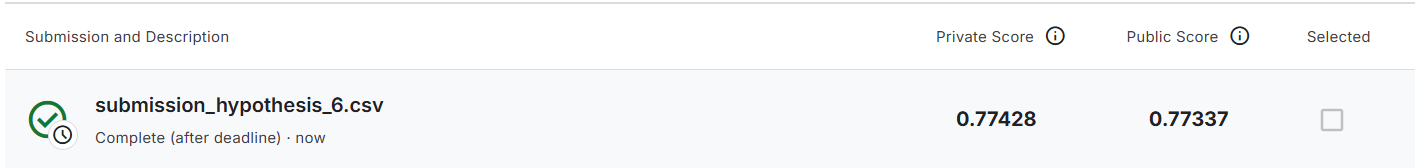

Гипотеза не подтвердилась